**Install PANNA package and download the training files and datasets:**


In [1]:
import os, sys, subprocess
from ase.io import read
from ase.visualize import view
from scripts import *

In [2]:
!{sys.executable} -m pip install jax
!{sys.executable} -m pip install tensorflow
!{sys.executable} -m pip install optax dm-haiku
!{sys.executable} -m pip install -r requirements.txt

  Using cached absl_py-2.1.0-py3-none-any.whl.metadata (2.3 kB)
  Using cached ase-3.22.1-py3-none-any.whl.metadata (3.1 kB)
  Using cached attrs-23.2.0-py3-none-any.whl.metadata (9.5 kB)
  Using cached certifi-2024.2.2-py3-none-any.whl.metadata (2.2 kB)
  Using cached charset_normalizer-3.3.2-py3-none-any.whl.metadata (33 kB)
  Using cached chex-0.1.85-py3-none-any.whl.metadata (17 kB)
  Using cached contextlib2-21.6.0-py2.py3-none-any.whl.metadata (4.1 kB)
  Using cached contourpy-1.2.0.tar.gz (13.5 MB)
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Installing backend dependencies ... done
  Preparing metadata (pyproject.toml) ... done
  Using cached dataclasses-0.6-py3-none-any.whl.metadata (3.0 kB)
  Using cached dm_haiku-0.0.12-py3-none-any.whl.metadata (19 kB)
  Using cached dm-tree-0.1.8.tar.gz (35 kB)
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
 

In [3]:
!git clone https://gitlab.com/PANNAdevs/panna.git
!{sys.executable} -m pip install ./panna

fatal: destination path 'panna' already exists and is not an empty directory.
Processing ./panna
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for PANNA: filename=panna-2.1.0-py3-none-any.whl size=140079 sha256=22cb9fa0f456d634891be3da1698d8dc06bba81ad0cd989ff6b719be85d7a9e9
  Stored in directory: /tmp/pip-ephem-wheel-cache-xcjhk0vu/wheels/15/d9/b0/4906629c4d13d7d98c1ad23ea9207b90c286ab31a152094876
Successfully built PANNA
  Attempting uninstall: PANNA
    Found existing installation: PANNA 2.1.0
    Uninstalling PANNA-2.1.0:
      Successfully uninstalled PANNA-2.1.0


In [4]:
! rm -rf CECAM_LATTE
! git clone https://github.com/Mina-T/CECAM_LATTE.git

Cloning into 'CECAM_LATTE'...
remote: Enumerating objects: 9709, done.
remote: Counting objects: 100% (9709/9709), done.
remote: Compressing objects: 100% (9599/9599), done.
remote: Total 9709 (delta 80), reused 9705 (delta 76), pack-reused 0 (from 0)
Receiving objects: 100% (9709/9709), 16.77 MiB | 26.14 MiB/s, done.
Resolving deltas: 100% (80/80), done.


**Let's visualize the Carbon dataset:**

In [5]:
os.chdir('/home/max/Desktop/CECAM_June2026/CECAM_LATTE')
file = ('dia_100/datasets/training_100_dia.xyz')
trajectory = read(file, index=":")
view(trajectory)

<Popen: returncode: None args: ['/home/max/.conda/envs/metatomic/bin/python'...>

**Step 1: train LATTE on a small diamond dataset.**

training set: 80 atomic structures, test set: 20 structures.

In [6]:
os.chdir('/home/max/Desktop/CECAM_June2026/CECAM_LATTE/dia_100/training')
!cat train.ini

[IO_INFORMATION]
# training dir, models are here under /models folder
train_dir = .  
# path to the training set
data_dir = ../datasets/training_set
# path to validation set
val_data_dir = ../datasets/validation_set
# set True if you would like to restart a training 
load_weights = True
# uncomment if you would like to start from a specific epoch
#weights_file = models/epoch_2110_step_2110000.pkl
# how frequently to save the model
save_epoch_freq = 50
# for accelerating the training
data_cache = True
[DATA_INFORMATION]
# list of elements present in training set
atomic_sequence = C
input_format = example   
output_offset = -253.67376683573406 

[MODEL_INFORMATION]
## Our standard model
model_type = MLP
## Architecture: l1:l2:l3
architecture = 32:16:1
# which descriptor, PANNA or LATTE
descriptor_type = LATTE
# more technical details, leave them as they are
nn_mode = list
pair_mod = 500
at_mod = 50
# the radius of atomic interaction
Rc = 5.0
sig = 1.0
# number of n-body interactions
desc

In [7]:
# %cd /home/max/Desktop/CECAM_June2026/panna/src
!{sys.executable} -m panna.train_jax -c train.ini

I0000 00:00:1782732996.839261   10525 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1782732997.419619   10525 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1782733000.712061   10525 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
E0000 00:00:1782733003.037459   10525 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)
INFO - 
    ____   _    _   _ _   _    _           
   |  _ \ / \  | \ | | \ | |  / \     
   | |_) / _ \ |  \| |  \| | / _ \     
   |  __/ ___ \| |\  | |\  |/ ___ \    
   |_| /_/   \_\_| \_|_| \_/_/   \_\ 

 Properties from Artificial Neural Network Architectures

INFO - reading train.ini
I0000 00:00:17827

Now, let's make prediction on Diamond test set.
Is this model able to predict more diverse dataset?

In [8]:
os.chdir('/home/max/Desktop/CECAM_June2026/CECAM_LATTE/dia_100/test_dia')
!{sys.executable} -m panna.train_jax -c train.ini
os.chdir('/home/max/Desktop/CECAM_June2026/CECAM_LATTE/dia_100/test_div')
!{sys.executable} -m panna.train_jax -c train.ini

I0000 00:00:1782735273.030999   12245 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1782735273.577200   12245 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1782735276.709143   12245 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
E0000 00:00:1782735278.717748   12245 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)
INFO - 
    ____   _    _   _ _   _    _           
   |  _ \ / \  | \ | | \ | |  / \     
   | |_) / _ \ |  \| |  \| | / _ \     
   |  __/ ___ \| |\  | |\  |/ ___ \    
   |_| /_/   \_\_| \_|_| \_/_/   \_\ 

 Properties from Artificial Neural Network Architectures

INFO - reading train.ini
Looking models in

Visualize the training and test error:

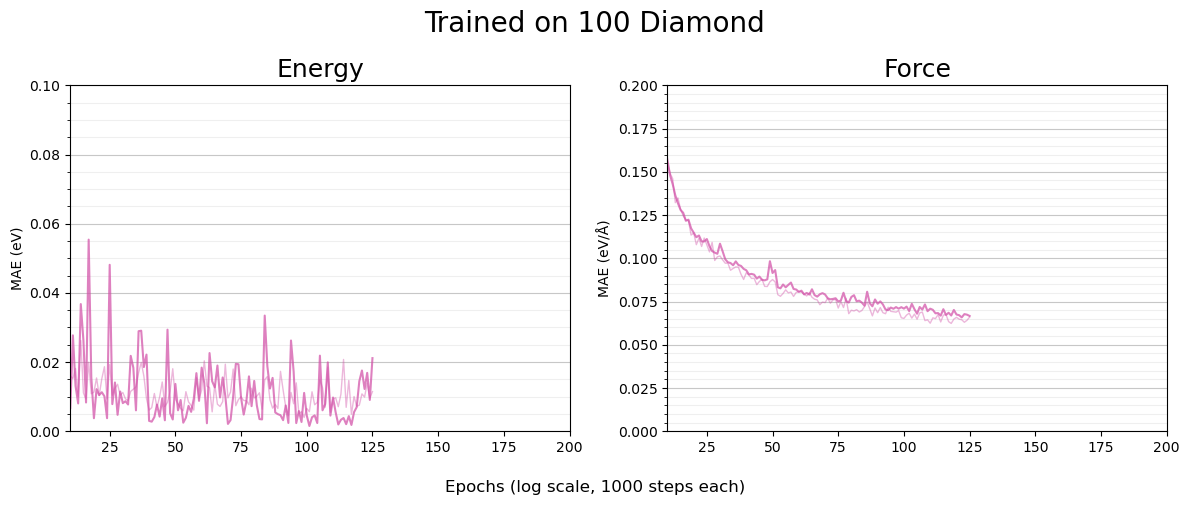

In [12]:
fig, axs = plt.subplots(1, 2, figsize = (12, 5))
plot_training('/home/max/Desktop/CECAM_June2026/CECAM_LATTE/dia_100/training', axs)
plot_setup(fig, axs, log=False, xlim=200, title='Trained on 100 Diamond')

In [11]:
path = '/home/max/Desktop/CECAM_June2026/CECAM_LATTE/dia_100/test_dia'
epoch = 50
Force_mae, Energy_mae= Force_MAE(path, epoch), Energy_MAE(path, epoch) 
print(f'At epoch {epoch}: \n Force_MAE: {Force_mae:.3f} \n Energy_MAE: {Energy_mae:.3f}')

At epoch 50: 
 Force_MAE: 0.119 
 Energy_MAE: 0.014


In [10]:
path = '/home/max/Desktop/CECAM_June2026/CECAM_LATTE/dia_100/test_div'
epoch = 50
Force_mae, Energy_mae= Force_MAE(path, epoch), Energy_MAE(path, epoch) 
print(f'At epoch {epoch}: \n Force_MAE: {Force_mae:.3f} \n Energy_MAE: {Energy_mae:.3f}')

At epoch 50: 
 Force_MAE: 0.843 
 Energy_MAE: 0.378
